# DATA PREPARATION

In [1]:
# ------------------------------------------
# INITIATION: PYTHON AND DISPLAY
# ------------------------------------------

# Import libraries
import pandas as pd #
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt #charts
import seaborn as sns #charts
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro, jarque_bera

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from statsmodels.regression.quantile_regression import QuantReg
import statsmodels.formula.api as smf

import shap

from sklearn.linear_model import LassoCV



# For better visibility
from IPython.display import display, HTML

# Apply a no-wrap style to prevent text wrapping
display(HTML("""
<style>
.dataframe td { white-space: nowrap; }
</style>
"""))

# Set the option to display all columns
pd.set_option('display.max_columns', None)

# Set the option to display all rows
pd.set_option('display.max_rows', None)

# Set the float format to use a space as a thousands separator and a comma as a decimal separator
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' ').replace('.', ','))

In [2]:
# ------------------------------------------
# FILE LOAD
# ------------------------------------------

# Read the Excel file into a DataFrame
df = pd.read_excel('2000 Analysis Python CHANGED.xlsx', decimal=',')
display (df.head())

,2023,2022,2021,2020,2019,Name,NIP,PKD,PKD Opis,Sector,Owner Type,Year,Sales,Gross Profit,Operating Profit,Net Profit,Depreciation,Export Sales,Employment,Staff costs,BS,Fixed Assets,Current Assets,Equity,Liabilities,PKD_2,PKD_1,PKD_1 Description,PKD_2 Description,Quartile of digital intensity: 2001-03,Quartile of digital intensity: 2013-15,Export as % of Sales,ROS,ROA,ROE,P/F,BS_Strength,Human_Capital,GVA,Productivity,Hint25,Hint50,HGX,HGX%,SGrowth_2023_2019,LSGrowth_2023_2019,RSGrowth_2023_2019,LRSGrowth_2023_2019,Annualised_Growth,Drop_Sales_2020,Drop_Sales_2023,Drop_Sales_Both,SGrowth_3,SGrowth_2,SGrowth_1,GVAGrowth_2023_2019,EGrowth_2023_2019,LEGrowth_2023_2019,Annualised_EGrowth,Drop_Employment,EGrowth_3,EGrowth_2,PGrowth_2023_2019,Starting_Profit,Starting_INT,Starting_BS_Strength,Starting_Size_arc,Starting_Size_ln,Starting_Human_Capital,Starting_GVA,Starting_Prod
0,2,"2,00","3,00","2,00",2,"Jeronimo Martins Polska SA, Kostrzyn",7791011327,4719,Pozostała sprzedaż detaliczna prowadzona w nie...,Retail,500,2023,"98 022 928,00","4 882 170,96","5 121 150,49","4 127 757,73","1 311 227,50","0,00","79 292,00","5 954 379,19","26 597 526,53","11 978 435,65","14 619 090,88","5 299 163,00","21 298 363,10",47,G,Wholesale and Retail Trade; Repair of Motor Ve...,"RETAIL TRADE, EXCEPT OF MOTOR VEHICLES",Medium-high,Medium-high,"0,00","0,04","0,16","0,78",F,"0,20","75,09","10 836 550,15","136,67",Exp<25,Exp<50,Decreased Export Intensity,"0,00","76,38","0,57","27,81","0,25","15,24",No,No,No,1.Moderate,2.Stable,Growing,"4 394 364,76","16,33","0,15","3,85",No,2.Hiring,Hiring,"42,15","0,04","0,00","0,23","18,53","17,83","53,43","6 442 185,39","94,52"
1,3,"3,00","4,00","3,00",4,"PGE Polska Grupa Energetyczna GK SA, Lublin",5260250541,7010,Działalność firm centralnych (head offices) i ...,Energy,145,2023,"95 964 000,00","-3 431 000,00","-4 055 000,00","-4 902 000,00","13 455 000,00","25 000,00","42 552,00","6 287 000,00","113 443 000,00","78 340 000,00","35 103 000,00","47 855 000,00","65 588 000,00",70,M,"Professional, Scientific and Technical Activities",ACTIVITIES OF HEAD OFFICES; MANAGEMENT CONSULT...,High,High,"0,00","-0,05","-0,04","-0,10",P,"0,42","147,75","2 856 000,00","67,12",Exp<25,Exp<50,Decreased Export Intensity,"-0,00","155,04","0,94","84,81","0,61","26,37",No,No,No,2.High,3.Growing,Growing,"2 373 000,00","1,47","0,01","0,37",Yes,1.Sustaining,Hiring,"55,60","-0,10","0,00","0,56","18,14","17,44","111,08","483 000,00","11,52"
2,4,"5,00","11,00","17,00",30,"Totalizator Sportowy sp. z o.o. GK, Warszawa",5250010982,9200,Działalność związana z grami losowymi i zakład...,Services,100,2023,"52 269 058,00","385 142,00","453 419,00","362 474,00","189 397,00","0,00","5 894,00","786 162,00","2 893 324,00","1 099 674,00","1 793 650,00","1 669 328,00","1 223 996,00",92,R,"Arts, Entertainment and Recreation",GAMBLING AND BETTING ACTIVITIES,Medium-low,Medium-high,"0,00","0,01","0,13","0,22",P,"0,58","133,38","1 171 304,00","198,73",Exp<25,Exp<50,Decreased Export Intensity,"0,00","428,35","1,66","282,86","1,34","51,61",No,No,No,3.Very High,3.Growing,Growing,"513 096,67","221,37","1,17","33,89",No,2.Hiring,Hiring,"-160,16","0,03","0,00","0,59","16,80","16,11","188,29","658 207,33","358,89"
3,5,"11,00","14,00","13,00",15,"Enea SA GK, Poznań",7770020640,3514,Handel energią elektryczną,Energy,145,2023,"48 183 419,00","955 679,00","-508 049,00","-442 623,00","1 651 920,00","0,00","17 853,00","3 092 964,00","39 110 745,00","21 636 978,00","17 473 767,00","15 439 599,00","23 671 146,00",35,D,"Electricity, Gas, Steam, Hot Water and Air Con...","ELECTRICITY, GAS, STEAM, HOT WATER AND AIR CON...",Low,Low,"0,00","-0,01","-0,01","-0,03",P,"0,39","173,25","4 048 643,00","226,78",Exp<25,Exp<50,Decreased Export Intensity,"0,00","205,03","1,12","121,04","0,79","32,16",No,No,No,3.Very High,3.Growing,Growing,"360 494,00","5,04","0,05","1,24",No,2.Hiring,Hiring,"9,78","0,03","0,00","0,47","17,27","16,58","112,03","3 688 149,00","217,00"
4,6,"6,00","13,00","11,00"

In [3]:
# ------------------------------------------
# VARIABLE MANAGEMENT TEMPLATE
# ------------------------------------------

# 1. Load your full dataset (already cleaned)
df_master = pd.read_excel("2000 Analysis Python CHANGED.xlsx")

# 2. Define variable groups
target_variable = 'LSGrowth_2023_2019'

# 🟨 ID & Metadata (for exclusion in all analysis)
id_columns = ['Name', 'NIP', 'PKD', 'PKD_1 Description', 'PKD_2 Description','2019', '2020', '2021', '2022', '2023']

# 🟥 Outcome-derived (Exclude from modeling but use in descriptive)
derived_outcomes = [
    'Annualised_Growth', 'Annualised_EGrowth', 'SGrowth_2023_2019','EGrowth_2023_2019','GVAGrowth_2023_2019',
    'PGrowth_2023_2019', '3_Growth_Categories','4_Growth_Categories',
    'EGrowth_Category','Hint'
]

# ✅ Modeling variables (filtered dynamically)
all_exclusions = id_columns + derived_outcomes

# 3. Build filtered dataset for modeling
df_model = df_master.copy()
df_model = df_model[df_model["Year"] == 2023]  # Example: focus on 2023
df_model = df_model.drop(columns=[col for col in all_exclusions if col in df_model.columns])

# 4. Optional: separate views for different tasks
modeling_features = [col for col in df_model.columns if col != target_variable]
descriptive_features = derived_outcomes

# Ready to use:
X_model = df_model[modeling_features]
y_model = df_model[target_variable]

display(df_model.head())

,PKD Opis,Sector,Owner Type,Year,Sales,Gross Profit,Operating Profit,Net Profit,Depreciation,Export Sales,Employment,Staff costs,BS,Fixed Assets,Current Assets,Equity,Liabilities,PKD_2,PKD_1,Quartile of digital intensity: 2001-03,Quartile of digital intensity: 2013-15,Export as % of Sales,ROS,ROA,ROE,P/F,BS_Strength,Human_Capital,GVA,Productivity,Hint25,Hint50,HGX,HGX%,LSGrowth_2023_2019,RSGrowth_2023_2019,LRSGrowth_2023_2019,Drop_Sales_2020,Drop_Sales_2023,Drop_Sales_Both,SGrowth_3,SGrowth_2,SGrowth_1,LEGrowth_2023_2019,Drop_Employment,EGrowth_3,EGrowth_2,Starting_Profit,Starting_INT,Starting_BS_Strength,Starting_Size_arc,Starting_Size_ln,Starting_Human_Capital,Starting_GVA,Starting_Prod
0,Pozostała sprzedaż detaliczna prowadzona w nie...,Retail,500,2023,"98 022 928,00","4 882 170,96","5 121 150,49","4 127 757,73","1 311 227,50","0,00","79 292,00","5 954 379,19","26 597 526,53","11 978 435,65","14 619 090,88","5 299 163,00","21 298 363,10",47,G,Medium-high,Medium-high,"0,00","0,04","0,16","0,78",F,"0,20","75,09","10 836 550,15","136,67",Exp<25,Exp<50,Decreased Export Intensity,"0,00","0,57","27,81","0,25",No,No,No,1.Moderate,2.Stable,Growing,"0,15",No,2.Hiring,Hiring,"0,04","0,00","0,23","18,53","17,83","53,43","6 442 185,39","94,52"
1,Działalność firm centralnych (head offices) i ...,Energy,145,2023,"95 964 000,00","-3 431 000,00","-4 055 000,00","-4 902 000,00","13 455 000,00","25 000,00","42 552,00","6 287 000,00","113 443 000,00","78 340 000,00","35 103 000,00","47 855 000,00","65 588 000,00",70,M,High,High,"0,00","-0,05","-0,04","-0,10",P,"0,42","147,75","2 856 000,00","67,12",Exp<25,Exp<50,Decreased Export Intensity,"-0,00","0,94","84,81","0,61",No,No,No,2.High,3.Growing,Growing,"0,01",Yes,1.Sustaining,Hiring,"-0,10","0,00","0,56","18,14","17,44","111,08","483 000,00","11,52"
2,Działalność związana z grami losowymi i zakład...,Services,100,2023,"52 269 058,00","385 142,00","453 419,00","362 474,00","189 397,00","0,00","5 894,00","786 162,00","2 893 324,00","1 099 674,00","1 793 650,00","1 669 328,00","1 223 996,00",92,R,Medium-low,Medium-high,"0,00","0,01","0,13","0,22",P,"0,58","133,38","1 171 304,00","198,73",Exp<25,Exp<50,Decreased Export Intensity,"0,00","1,66","282,86","1,34",No,No,No,3.Very High,3.Growing,Growing,"1,17",No,2.Hiring,Hiring,"0,03","0,00","0,59","16,80","16,11","188,29","658 207,33","358,89"
3,Handel energią elektryczną,Energy,145,2023,"48 183 419,00","955 679,00","-508 049,00","-442 623,00","1 651 920,00","0,00","17 853,00","3 092 964,00","39 110 745,00","21 636 978,00","17 473 767,00","15 439 599,00","23 671 146,00",35,D,Low,Low,"0,00","-0,01","-0,01","-0,03",P,"0,39","173,25","4 048 643,00","226,78",Exp<25,Exp<50,Decreased Export Intensity,"0,00","1,12","121,04","0,79",No,No,No,3.Very High,3.Growing,Growing,"0,05",No,2.Hiring,Hiring,"0,03","0,00","0,47","17,27","16,58","112,03","3 688 149,00","217,00"
4,Handel energią elektryczną,Energy,145,2023,"42 657 000,00","3 394 000,00","2 302 000,00","1 678 000,00","2 226 000,00","753 000,00","18 946,00","2 851 000,00","49 798 000,00","37 353 000,00","12 445 000,00","17 953 000,00","31 845 000,00",35,D,Low,Low,"0,02","0,04","0,03","0,09",P,"0,36","150,48","6 245 000,00","329,62",Exp<25,Exp<50,Increased Export Intensity,"0,01","0,80","61,73","0,48",No,No,No,2.High,3.Growing,Growing,"-0,32",Yes,0.Reducing,Reducing,"-0,00","0,01","0,46","17,46","16,77","98,27","2 762 520,00","105,90"


# OLS Regression

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     LSGrowth_2023_2019   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     11.84
Date:                Tue, 27 May 2025   Prob (F-statistic):           2.37e-37
Time:                        09:54:18   Log-Likelihood:                -491.84
No. Observations:                1489   AIC:                             1028.
Df Residuals:                    1467   BIC:                             1144.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              0.3558      0.028     12.880      0.000       0.302       0.410
Starting_INT                      -0.0049      0.010     -0.478      0.633      -0.025       0.015
Starting_BS_Strength               0.0031      0.009      0.333      0.739      -0.015       0.022
Starting_Size_ln                  -0.0825      0.011     -7.453      0.000      -0.104      -0.061
Starting_Human_Capital            -0.0014      0.009     -0.156      0.876      -0.020       0.017
Starting_GVA                       0.0340      0.011      3.053      0.002       0.012       0.056
Starting_Prod                     -0.0023      0.009     -0.244      0.807      -0.021       0.016
P/F_P                              0.0396      0.019      2.095      0.036       0.003       0.077
Sector_Chemicals                   0.0310      0.057      0.540      0.589      -0.082       0.144
Sector_Construction               -0.0216      0.037     -0.580      0.562      -0.095       0.051
Sector_Energy                      0.8568      0.071     12.020      0.000       0.717       0.997
Sector_Food                        0.0659      0.036      1.831      0.067      -0.005       0.137
Sector_Healthcare and pharma      -0.0072      0.048     -0.152      0.879      -0.100       0.086
Sector_Media, telco and IT        -0.0336      0.045     -0.743      0.458      -0.122       0.055
Sector_Mining and metallurgy      -0.0671      0.066     -1.017      0.309      -0.196       0.062
Sector_Oil                         0.0058      0.057      0.101      0.919      -0.107       0.118
Sector_Production                 -0.0449      0.032     -1.395      0.163      -0.108       0.018
Sector_Retail                     -0.0119      0.051     -0.232      0.816      -0.112       0.088
Sector_Services                    0.0285      0.046      0.613      0.540      -0.063       0.120
Sector_Transportation             -0.0253      0.046     -0.552      0.581      -0.115       0.065
Sector_Wholesale                  -0.0388      0.039     -0.998      0.318      -0.115       0.037
HGX_Increased Export Intensity     0.0338      0.018      1.857      0.063      -0.002       0.069
==============================================================================
Omnibus:                      799.521   Durbin-Watson:                   1.759
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            23186.066
Skew:                           1.932   Prob(JB):                         0.00
Kurtosis:                      21.942   Cond. No.                         15.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

,Variable,VIF
0,const,"9,88"
1,Starting_INT,"1,36"
2,Starting_BS_Strength,"1,14"
3,Starting_Size_ln,"1,59"
4,Starting_Human_Capital,"1,12"
5,Starting_GVA,"1,61"
6,Starting_Prod,"1,13"
7,P/F_P,"1,16"
8,Sector_Chemicals,"1,22"
9,Sector_Construction,"1,78"


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


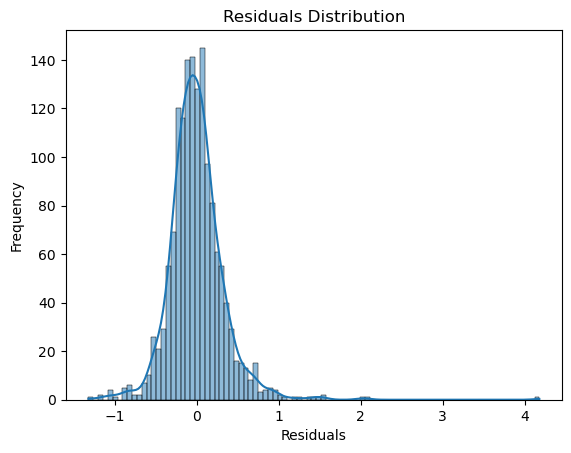

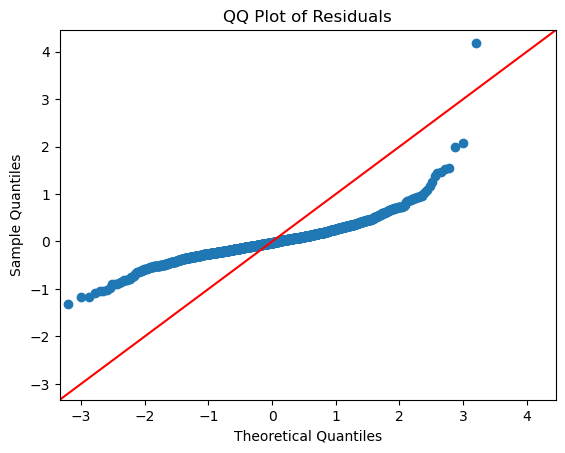

🔍 Shapiro-Wilk Test (normality):
  Statistic = 0.8924
  p-value   = 0.0000

📦 Jarque-Bera Test (skew + kurtosis):
  Statistic = 23186.0656
  p-value   = 0.0000


In [4]:
# STEP 1: FILTER TO YEAR 2023
df_2023 = df_model[df_model['Year'] == 2023]

# STEP 2: DEFINE VARIABLES
numeric_features = [
    'Starting_INT', 'Starting_BS_Strength',
    'Starting_Size_ln', 'Starting_Human_Capital','Starting_GVA','Starting_Prod'
]
categorical_vars = ['P/F', 'Sector', 'HGX']
target = target_variable

# STEP 3: DROP MISSING VALUES
all_vars = numeric_features + categorical_vars + [target]
df_clean = df_2023.dropna(subset=all_vars)

# STEP 4: STANDARDIZE NUMERIC VARIABLES
X_numeric = pd.DataFrame(
    StandardScaler().fit_transform(df_clean[numeric_features]),
    columns=numeric_features,
    index=df_clean.index
)

# STEP 5: ENCODE CATEGORICAL VARIABLES (drop_first to avoid dummy trap)
X_categorical = pd.get_dummies(df_clean[categorical_vars], drop_first=True)

# STEP 6: COMBINE FEATURES AND ADD CONSTANT
X_full = pd.concat([X_numeric, X_categorical], axis=1)
X_full = sm.add_constant(X_full).astype(float)  # Ensure numeric

# STEP 7: DEFINE TARGET
y = df_clean[target]

# STEP 8: FIT OLS REGRESSION MODEL
model = sm.OLS(y, X_full).fit()
display(model.summary())

# STEP 9: CALCULATE VIF TO CHECK MULTICOLLINEARITY
vif_data = pd.DataFrame({
    "Variable": X_full.columns,
    "VIF": [variance_inflation_factor(X_full.values, i) for i in range(X_full.shape[1])]
})
display(vif_data)

residuals = model.resid.replace([np.inf, -np.inf], np.nan).dropna()

# STEP 10: CLEAN RESIDUALS
residuals = model.resid.replace([np.inf, -np.inf], np.nan).dropna()

# STEP 11: RESIDUALS DISTRIBUTION PLOT
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# STEP 12: QQ PLOT
sm.qqplot(residuals, line='45')
plt.title("QQ Plot of Residuals")
plt.show()

# Run statistical tests on residuals
shapiro_test = shapiro(residuals)
jb_test = jarque_bera(residuals)

# Display results
print("🔍 Shapiro-Wilk Test (normality):")
print(f"  Statistic = {shapiro_test.statistic:.4f}")
print(f"  p-value   = {shapiro_test.pvalue:.4f}")

print("\n📦 Jarque-Bera Test (skew + kurtosis):")
print(f"  Statistic = {jb_test.statistic:.4f}")
print(f"  p-value   = {jb_test.pvalue:.4f}")

In [5]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

# STEP A: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.3, random_state=42)

# STEP B: Fit OLS Model on Training Data
model_train = sm.OLS(y_train, X_train).fit()

# STEP C: Make Predictions on Testing Data
y_test_pred = model_train.predict(X_test)

# STEP D: Evaluate Model Performance
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Display Test Performance
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test Mean Squared Error: {test_mse:.4f}")


Test R² Score: 0.1291
Test Mean Squared Error: 0.1116


 # Random Forest Feature and Permutations Importance

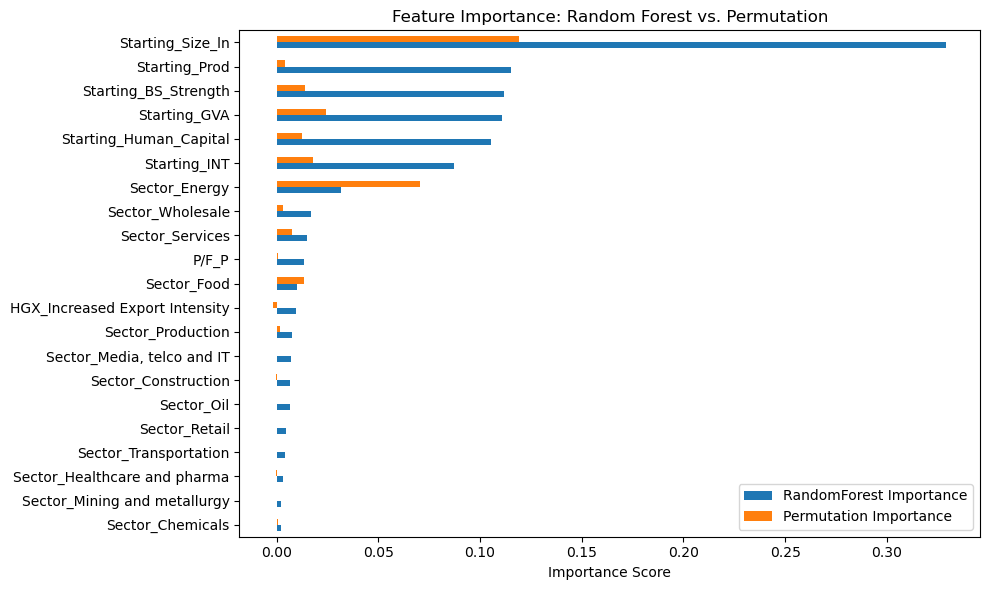

,RandomForest Importance,Permutation Importance
Starting_Size_ln,"0,33","0,12"
Starting_Prod,"0,12","0,00"
Starting_BS_Strength,"0,11","0,01"
Starting_GVA,"0,11","0,02"
Starting_Human_Capital,"0,11","0,01"
Starting_INT,"0,09","0,02"
Sector_Energy,"0,03","0,07"
Sector_Wholesale,"0,02","0,00"
Sector_Services,"0,01","0,01"
P/F_P,"0,01","0,00"


R^2 Score: 0.0788
Mean Squared Error: 0.1180


In [6]:
# 1. Drop 'const' and define input/output
X_rf = X_full.drop(columns='const')
y_rf = y

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.3, random_state=42)

# 3. Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Random Forest Feature Importance
rf_importances = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)

# 5. Permutation Importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
perm_importances = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

# 6. Combine into one DataFrame
importance_df = pd.DataFrame({
    'RandomForest Importance': rf_importances,
    'Permutation Importance': perm_importances
}).sort_values(by='RandomForest Importance', ascending=True)

# 7. Plot
importance_df.plot(kind='barh', figsize=(10, 6))
plt.title("Feature Importance: Random Forest vs. Permutation")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# 8. Display numeric table
importance_df = importance_df.sort_values(by='RandomForest Importance', ascending=False)
display(importance_df)

# 9. Model Evaluation
from sklearn.metrics import r2_score, mean_squared_error

y_pred = rf.predict(X_test)

# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R^2 Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")


# Random Forest Optimised

Fitting 10 folds for each of 200 candidates, totalling 2000 fits
[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.6s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.3s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.3s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=None, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimator

[CV] END bootstrap=True, max_depth=20, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=8, min_samples_split=20, n_estimators=1000; total time=   1.4s
[CV] END bootstrap=False, max_depth=10, max_features=0.5, min_samples_leaf=8, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END bootstrap=False, max_depth=10, max_features=0.5, min_samples_leaf=8, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END bootstrap=True, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=700; total time=   2.4s
[CV] END bootstrap=False, max_depth=30, max_features=0.75, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   1.6s
[CV] END bootstrap=False, max_depth=30, max_features=0.75, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   1.5s
[CV] END bootstrap=False, max_depth=None, max_

[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=8, min_samples_split=5, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=15, n_estimators=700; total time=   0.6s
[CV] END bootstrap=True, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=15, n_estimators=700; total time=   0.7s
[CV] END bootstrap=True, max_depth=15, max_features=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   2.1s
[CV] END bootstrap=True, max_depth=5, max_features=0.75, min_samples_leaf=4, min_samples_split=2, n_estimators=300; total time=   0.5s
[CV] END bootstrap=True, max_depth=5, max_features=0.75, min_samples_leaf=4, min_samples_split=2, n_estimators=300; total time=   0.5s
[CV] END bootstrap=False, max_depth=15, max_features=sqrt, min_samples_leaf=6, min_samples_split=5, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=15, max_feature

[CV] END bootstrap=False, max_depth=20, max_features=1.0, min_samples_leaf=4, min_samples_split=20, n_estimators=300; total time=   1.6s
[CV] END bootstrap=False, max_depth=20, max_features=1.0, min_samples_leaf=4, min_samples_split=20, n_estimators=300; total time=   1.6s
[CV] END bootstrap=False, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time=   0.9s
[CV] END bootstrap=True, max_depth=30, max_features=0.3, min_samples_leaf=6, min_samples_split=10, n_estimators=1000; total time=   1.5s
[CV] END bootstrap=False, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=15, n_estimators=500; total time=   0.4s
[CV] END bootstrap=False, max_depth=None, max_features=1.0, min_samples_leaf=4, min_samples_split=2, n_estimators=1000; total time=   5.8s
[CV] END bootstrap=False, max_depth=None, max_features=0.5, min_samples_leaf=8, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END bootstrap=False, max_depth=N

[CV] END bootstrap=False, max_depth=15, max_features=0.5, min_samples_leaf=1, min_samples_split=15, n_estimators=500; total time=   1.5s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=15, n_estimators=1000; total time=   1.2s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=15, n_estimators=1000; total time=   1.2s
[CV] END bootstrap=True, max_depth=None, max_features=1.0, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=8, min_samples_split=15, n_estimators=1000; total time=   2.0s
[CV] END bootstrap=False, max_depth=10, max_features=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=700; total time=   1.9s
[CV] END bootstrap=False, max_depth=10, max_features=1.0, min_samples_leaf=2, min_samples_split=10, n_estimators=700; total time=   3.5s
[CV] END bootstrap=True, max_depth=5, m

[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.6s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.6s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=10, ma

[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=8, min_samples_split=20, n_estimators=500; total time=   0.6s
[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=8, min_samples_split=20, n_estimators=500; total time=   0.6s
[CV] END bootstrap=False, max_depth=5, max_features=0.75, min_samples_leaf=6, min_samples_split=2, n_estimators=500; total time=   1.1s
[CV] END bootstrap=True, max_depth=20, max_features=0.3, min_samples_leaf=4, min_samples_split=5, n_estimators=700; total time=   1.2s
[CV] END bootstrap=True, max_depth=20, max_features=0.3, min_samples_leaf=4, min_samples_split=5, n_estimators=700; total time=   1.7s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=300; total time=   0.4s
[CV] END bootstrap=True, max_depth=None, max_f

[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=1, min_samples_split=5, n_estimators=700; total time=   1.6s
[CV] END bootstrap=False, max_depth=10, max_features=1.0, min_samples_leaf=4, min_samples_split=15, n_estimators=500; total time=   2.2s
[CV] END bootstrap=True, max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=15, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=15, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=8, min_samples_split=20, n_estimators=700; total time=   1.3s
[CV] END bootstrap=False, max_depth=15, max_features=1.0, min_samples_leaf=2, min_samples_split=20, n_estimators=1000; total time=   6.5s
[CV] END bootstrap=True, max_depth=5, max_features=1.0, min_samples_leaf=6, min_samples_split=15, n_estimators=700; total time=   1.8s
[CV] END bootstrap=True, max_depth=5, max_fea

[CV] END bootstrap=False, max_depth=20, max_features=0.5, min_samples_leaf=4, min_samples_split=15, n_estimators=500; total time=   1.4s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_leaf=6, min_samples_split=15, n_estimators=1000; total time=   1.3s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_leaf=6, min_samples_split=15, n_estimators=1000; total time=   1.2s
[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=8, min_samples_split=20, n_estimators=500; total time=   0.6s
[CV] END bootstrap=False, max_depth=5, max_features=0.75, min_samples_leaf=6, min_samples_split=2, n_estimators=500; total time=   1.1s
[CV] END bootstrap=True, max_depth=20, max_features=0.3, min_samples_leaf=4, min_samples_split=5, n_estimators=700; total time=   1.2s
[CV] END bootstrap=True, max_depth=20, max_features=0.3, min_samples_leaf=4, min_samples_split=5, n_estimators=700; total time=   1.8s
[CV] END bootstrap=True, max_depth=None, max

[CV] END bootstrap=True, max_depth=5, max_features=0.75, min_samples_leaf=6, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=20, max_features=1.0, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   3.3s
[CV] END bootstrap=False, max_depth=20, max_features=1.0, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   3.4s
[CV] END bootstrap=True, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=15, n_estimators=700; total time=   0.6s
[CV] END bootstrap=True, max_depth=15, max_features=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   2.1s
[CV] END bootstrap=True, max_depth=15, max_features=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   2.1s
[CV] END bootstrap=True, max_depth=15, max_features=0.3, min_samples_leaf=4, min_samples_split=2, n_estimators=700; total time=   1.0s
[CV] END bootstrap=True, max_depth=5, max_features

[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=1000; total time=   2.0s
[CV] END bootstrap=False, max_depth=15, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=15, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=15, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=15, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=15, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, max_depth=None, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=500; total time=   0.8s
[CV] END bootstrap=True, max_depth=None

[CV] END bootstrap=False, max_depth=10, max_features=0.75, min_samples_leaf=4, min_samples_split=20, n_estimators=700; total time=   2.4s
[CV] END bootstrap=False, max_depth=10, max_features=0.75, min_samples_leaf=4, min_samples_split=20, n_estimators=700; total time=   2.3s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=15, n_estimators=1000; total time=   1.2s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=15, n_estimators=1000; total time=   1.2s
[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=8, min_samples_split=15, n_estimators=1000; total time=   1.9s
[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=8, min_samples_split=15, n_estimators=1000; total time=   1.8s
[CV] END bootstrap=False, max_depth=10, max_features=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=700; total time=   1.8s
[CV] END bootstrap=False, max_depth=

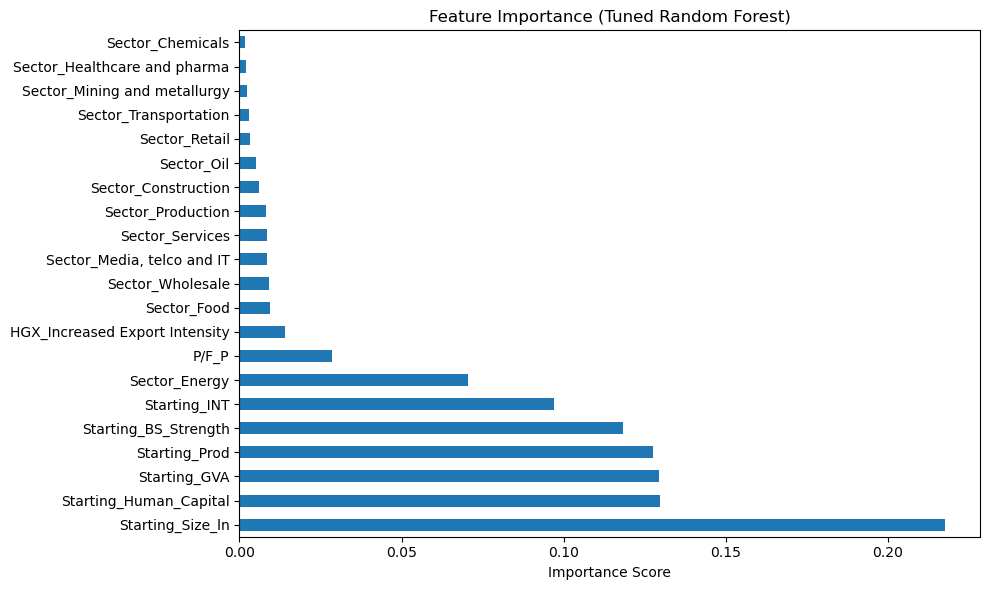

,Feature,Importance
2,Starting_Size_ln,"0,22"
3,Starting_Human_Capital,"0,13"
4,Starting_GVA,"0,13"
5,Starting_Prod,"0,13"
1,Starting_BS_Strength,"0,12"
0,Starting_INT,"0,10"
9,Sector_Energy,"0,07"
6,P/F_P,"0,03"
20,HGX_Increased Export Intensity,"0,01"
10,Sector_Food,"0,01"


In [7]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# 1. Drop 'const' and define input/output
X_rf = X_full.drop(columns='const')
y_rf = y

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.3, random_state=42)

# 3. Define Random Forest Model
rf = RandomForestRegressor(random_state=42)

# 4. Define Hyperparameter Grid for Random Search (updated to remove 'auto')
param_grid = {
    'n_estimators': [100, 300, 500, 700, 1000],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': [1.0, 'sqrt', 'log2', 0.3, 0.5, 0.75],
    'bootstrap': [True, False]
}

# 5. Initialize RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=200,  # Increased for better tuning
    scoring='r2',  # Can also try 'neg_mean_squared_error'
    cv=10,  # Increased cross-validation for robustness
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 6. Fit the model with RandomizedSearchCV
rf_random.fit(X_train, y_train)

# 7. Extract the Best Hyperparameters & Score
best_params = rf_random.best_params_
best_score = rf_random.best_score_

print("Best Hyperparameters:", best_params)
print(f"Best R² Score from Cross-Validation: {best_score:.4f}")

# 8. Train the Final Model using Best Hyperparameters
best_rf = RandomForestRegressor(**best_params, random_state=42)
best_rf.fit(X_train, y_train)

# 9. Make Predictions on Training and Test Data
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# 10. Evaluate the Tuned Model (Train & Test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Print Results
print(f"\nTraining Performance:")
print(f"Train R² Score: {train_r2:.4f}")
print(f"Train Mean Squared Error: {train_mse:.4f}")

print(f"\nTest Performance:")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test Mean Squared Error: {test_mse:.4f}")

# === Debugging Check Before Step 11 ===

# Checking the number of features before model training
print(f"\nNumber of features in X_rf: {X_rf.shape[1]}")
print(f"Number of feature importances from Random Forest: {len(best_rf.feature_importances_)}")

# Make sure all columns match correctly
if X_rf.shape[1] == len(best_rf.feature_importances_):
    # 11. Feature Importance Plot
    rf_importances = pd.Series(best_rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    rf_importances.plot(kind='barh')
    plt.title("Feature Importance (Tuned Random Forest)")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

    # 12. Display Feature Importances in DataFrame
    importance_df = pd.DataFrame({
        'Feature': X_rf.columns,
        'Importance': best_rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    display(importance_df)
else:
    print("⚠️ Feature mismatch detected! Ensure preprocessing steps are consistent.")


# OLS vs Random Forest


Metric                    OLS        Random Forest (Test)
--------------------------------------------------
R² Score                  0.1450      0.1047
MSE                       0.1134      0.1147
MAE                       0.2321      0.2374


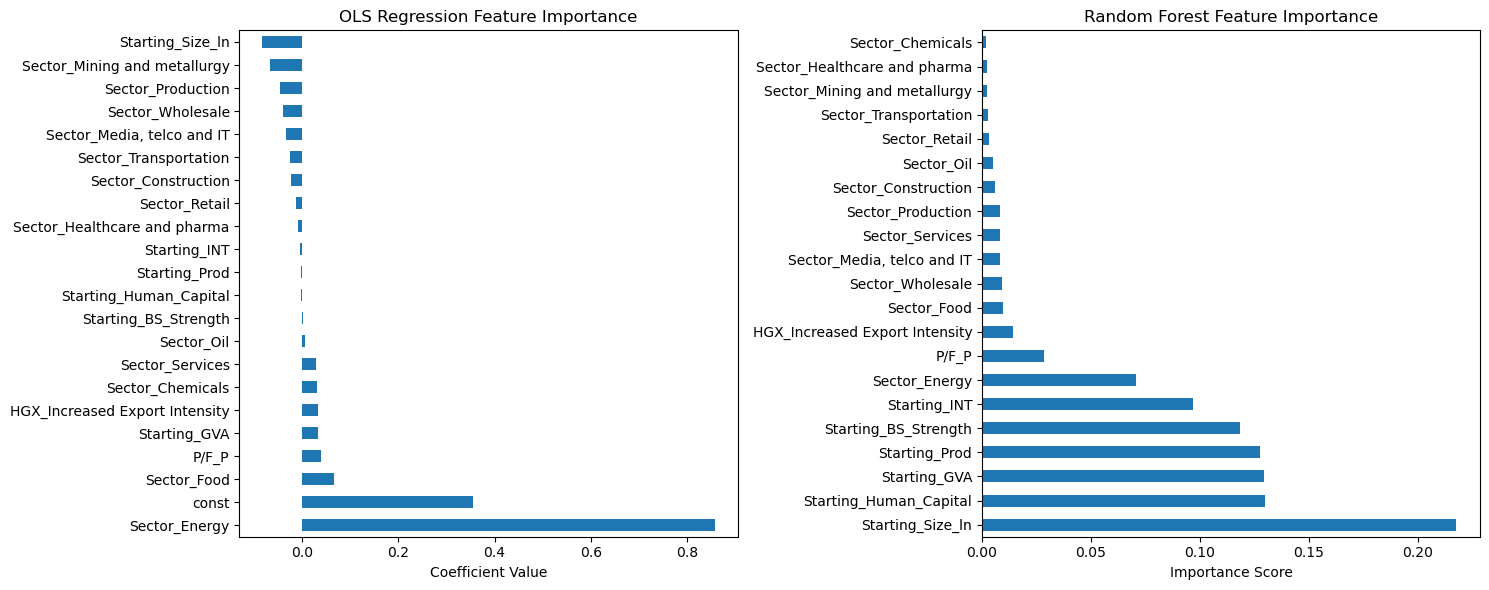

,OLS Coefficients,RF Importance
Starting_Size_ln,"-0,08","0,22"
Starting_Human_Capital,"-0,00","0,13"
Starting_GVA,"0,03","0,13"
Starting_Prod,"-0,00","0,13"
Starting_BS_Strength,"0,00","0,12"
Starting_INT,"-0,00","0,10"
Sector_Energy,"0,86","0,07"
P/F_P,"0,04","0,03"
HGX_Increased Export Intensity,"0,03","0,01"
Sector_Food,"0,07","0,01"


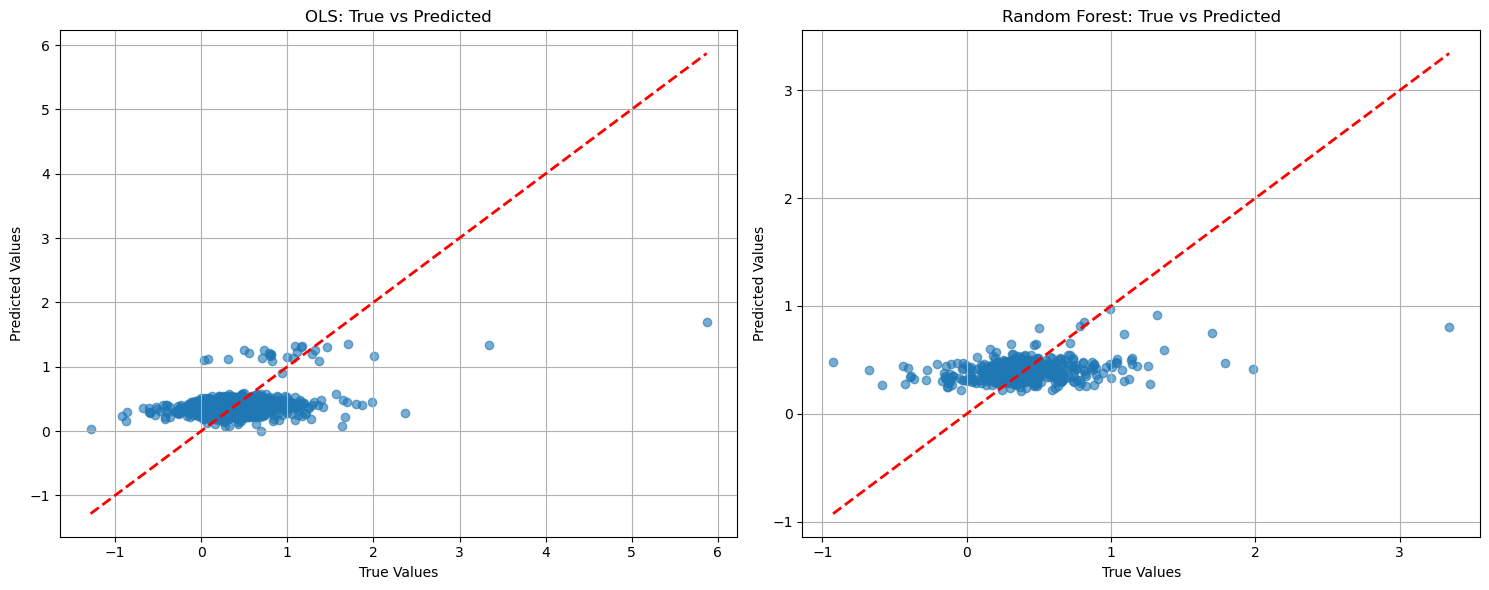

In [8]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error


# === Comparison of Performance Metrics ===
ols_pred = model.predict(X_full)
ols_r2 = r2_score(y, ols_pred)
ols_mse = mean_squared_error(y, ols_pred)
ols_mae = mean_absolute_error(y, ols_pred)

rf_train_r2 = train_r2
rf_test_r2 = test_r2
rf_train_mse = train_mse
rf_test_mse = test_mse
rf_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n{'Metric':<25} {'OLS':<10} {'Random Forest (Test)':<10}")
print(f"{'-'*50}")
print(f"{'R² Score':<25} {ols_r2:.4f}      {rf_test_r2:.4f}")
print(f"{'MSE':<25} {ols_mse:.4f}      {rf_test_mse:.4f}")
print(f"{'MAE':<25} {ols_mae:.4f}      {rf_mae:.4f}")

# === Plotting Feature Importance for OLS and Random Forest ===
ols_importances = pd.Series(model.params.values, index=model.params.index).sort_values(ascending=False)
rf_importances = pd.Series(best_rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
ols_importances.plot(kind='barh')
plt.title("OLS Regression Feature Importance")
plt.xlabel("Coefficient Value")

plt.subplot(1, 2, 2)
rf_importances.plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()

# === Comparing Top 20 Features from Both Models ===
importance_comparison = pd.DataFrame({
    'OLS Coefficients': ols_importances,
    'RF Importance': rf_importances
}).sort_values(by='RF Importance', ascending=False)

display(importance_comparison.head(20))

# === Visual Comparison of Predictions ===
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(y, ols_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('OLS: True vs Predicted')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: True vs Predicted')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid(True)

plt.tight_layout()
plt.show()

# QUANTILE REGRESSION

In [9]:
# STEP 8: FIT QUANTILE REGRESSION MODEL (for Quantile 0.25)
quantile = 0.5  # Adjust this value for different quantiles (0.25, 0.5, 0.75, etc.)
model = QuantReg(y, X_full).fit(q=quantile)

# Display model summary
display(model.summary())

# STEP 9: Calculate Pseudo R² (for comparison with OLS and other quantiles)
y_pred = model.predict(X_full)
S_fitted = np.sum(np.abs(y - y_pred))
S_baseline = np.sum(np.abs(y - np.mean(y)))
pseudo_r2 = 1 - (S_fitted / S_baseline)
display(f"\nPseudo R² for Quantile {quantile}: {pseudo_r2 * 100:.2f}%")

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:     LSGrowth_2023_2019   Pseudo R-squared:              0.04832
Model:                       QuantReg   Bandwidth:                      0.1053
Method:                 Least Squares   Sparsity:                       0.5811
Date:                Tue, 27 May 2025   No. Observations:                 1489
Time:                        10:03:30   Df Residuals:                     1467
                                        Df Model:                           21
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              0.3092      0.024     13.067      0.000       0.263       0.356
Starting_INT                       0.0042      0.009      0.479      0.632      -0.013       0.021
Starting_BS_Strength              -0.0057      0.008     -0.704      0.482      -0.021       0.010
Starting_Size_ln                  -0.0408      0.009     -4.302      0.000      -0.059      -0.022
Starting_Human_Capital            -0.0029      0.008     -0.360      0.719      -0.018       0.013
Starting_GVA                       0.0184      0.010      1.922      0.055      -0.000       0.037
Starting_Prod                     -0.0045      0.008     -0.561      0.575      -0.020       0.011
P/F_P                              0.0250      0.016      1.541      0.124      -0.007       0.057
Sector_Chemicals                   0.0905      0.049      1.840      0.066      -0.006       0.187
Sector_Construction                0.0253      0.032      0.793      0.428      -0.037       0.088
Sector_Energy                      0.7212      0.061     11.812      0.000       0.601       0.841
Sector_Food                        0.0977      0.031      3.167      0.002       0.037       0.158
Sector_Healthcare and pharma       0.0332      0.041      0.814      0.416      -0.047       0.113
Sector_Media, telco and IT        -0.0585      0.039     -1.511      0.131      -0.134       0.017
Sector_Mining and metallurgy      -0.0434      0.056     -0.768      0.443      -0.154       0.067
Sector_Oil                         0.0841      0.049      1.713      0.087      -0.012       0.180
Sector_Production                 -0.0159      0.028     -0.576      0.565      -0.070       0.038
Sector_Retail                      0.0281      0.044      0.642      0.521      -0.058       0.114
Sector_Services                    0.0790      0.040      1.985      0.047       0.001       0.157
Sector_Transportation              0.0331      0.039      0.842      0.400      -0.044       0.110
Sector_Wholesale                   0.0157      0.033      0.473      0.637      -0.050       0.081
HGX_Increased Export Intensity     0.0335      0.016      2.153      0.031       0.003       0.064
==================================================================================================
"""

'\nPseudo R² for Quantile 0.5: 5.43%'

[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=20, n_estimators=1000; total time=   1.3s
[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=20, n_estimators=1000; total time=   1.3s
[CV] END bootstrap=True, max_depth=None, max_features=0.3, min_samples_leaf=6, min_samples_split=20, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=5, max_features=sqrt, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.5s
[CV] END bootstrap=False, max_depth=5, max_features=sqrt, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.5s
[CV] END bootstrap=False, max_depth=20, max_features=0.75, min_samples_leaf=4, min_samples_split=20, n_estimators=300; total time=   1.3s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=1000; total time=   1.3s
[CV] END bootstrap=False, max_depth=30,

[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=8, min_samples_split=20, n_estimators=700; total time=   0.9s
[CV] END bootstrap=True, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=1000; total time=   3.4s
[CV] END bootstrap=True, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=1000; total time=   3.6s
[CV] END bootstrap=False, max_depth=20, max_features=0.75, min_samples_leaf=4, min_samples_split=20, n_estimators=300; total time=   1.3s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=1000; total time=   1.4s
[CV] END bootstrap=False, max_depth=30, ma

[CV] END bootstrap=False, max_depth=10, max_features=0.5, min_samples_leaf=8, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END bootstrap=True, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=700; total time=   2.5s
[CV] END bootstrap=False, max_depth=30, max_features=0.75, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   1.5s
[CV] END bootstrap=False, max_depth=30, max_features=0.75, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   1.6s
[CV] END bootstrap=False, max_depth=None, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=700; total time=   1.3s
[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=1000; total time=   1.3s
[CV] END bootstrap=True, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=5, max_

[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=20, n_estimators=300; total time=   0.4s
[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=6, min_samples_split=20, n_estimators=1000; total time=   1.8s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=6, min_samples_split=15, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=6, min_samples_split=15, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=6, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=5, m

[CV] END bootstrap=True, max_depth=None, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=500; total time=   0.8s
[CV] END bootstrap=True, max_depth=15, max_features=0.3, min_samples_leaf=6, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=8, min_samples_split=20, n_estimators=700; total time=   0.9s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=8, min_samples_split=20, n_estimators=700; total time=   0.9s
[CV] END bootstrap=True, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=1000; total time=   3.4s
[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=20, n_estimators=1000; total time=   1.3s
[CV] END bootstrap=True, max_depth=None, max_features=0.3, min_samples_leaf=6, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, ma

[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=8, min_samples_split=20, n_estimators=1000; total time=   1.4s
[CV] END bootstrap=True, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=700; total time=   2.5s
[CV] END bootstrap=False, max_depth=30, max_features=0.75, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   1.6s
[CV] END bootstrap=False, max_depth=30, max_features=0.75, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   1.6s
[CV] END bootstrap=False, max_depth=None, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=700; total time=   1.3s
[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=1000; total time=   1.4s
[CV] END bootstrap=False, max_depth=20, max_features=0.5, min_samples_leaf=6, min_samples_split=15, n_estimators=100; total time=   0.3s
[CV] END bootstrap=False, max_depth=20, m

[CV] END bootstrap=False, max_depth=20, max_features=0.5, min_samples_leaf=6, min_samples_split=15, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, max_depth=15, max_features=1.0, min_samples_leaf=4, min_samples_split=15, n_estimators=1000; total time=   4.8s
[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=1000; total time=   2.1s
[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=1000; total time=   2.2s
[CV] END bootstrap=True, max_depth=None, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=500; total time=   0.8s
[CV] END bootstrap=True, max_depth=15, max_features=0.3, min_samples_leaf=6, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=15,

[CV] END bootstrap=True, max_depth=15, max_features=1.0, min_samples_leaf=4, min_samples_split=15, n_estimators=1000; total time=   4.8s
[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=1000; total time=   2.1s
[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=1000; total time=   2.4s
[CV] END bootstrap=True, max_depth=15, max_features=0.3, min_samples_leaf=6, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=15, max_features=0.3, min_samples_leaf=6, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=8, min_samples_split=20, n_estimators=700; total time=   0.9s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=8, min_samples_split=20, n_estimators=700; total time=   0.9s
[CV] END bootstrap=True, max_depth=10, max_fe

# SHAP Analysis

,Feature,Mean |SHAP Value|
0,Drop_Sales_2020_Yes,"0,14"
1,Drop_Sales_2023_Yes,"0,09"
2,Starting_Size,"0,06"
3,Starting_BS_Strength,"0,03"
4,PKD_1_D,"0,02"
5,Starting_Prod,"0,02"
6,Starting_GVA,"0,02"
7,Starting_Human_Capital,"0,02"
8,Starting_INT,"0,02"
9,Starting_Profit,"0,01"


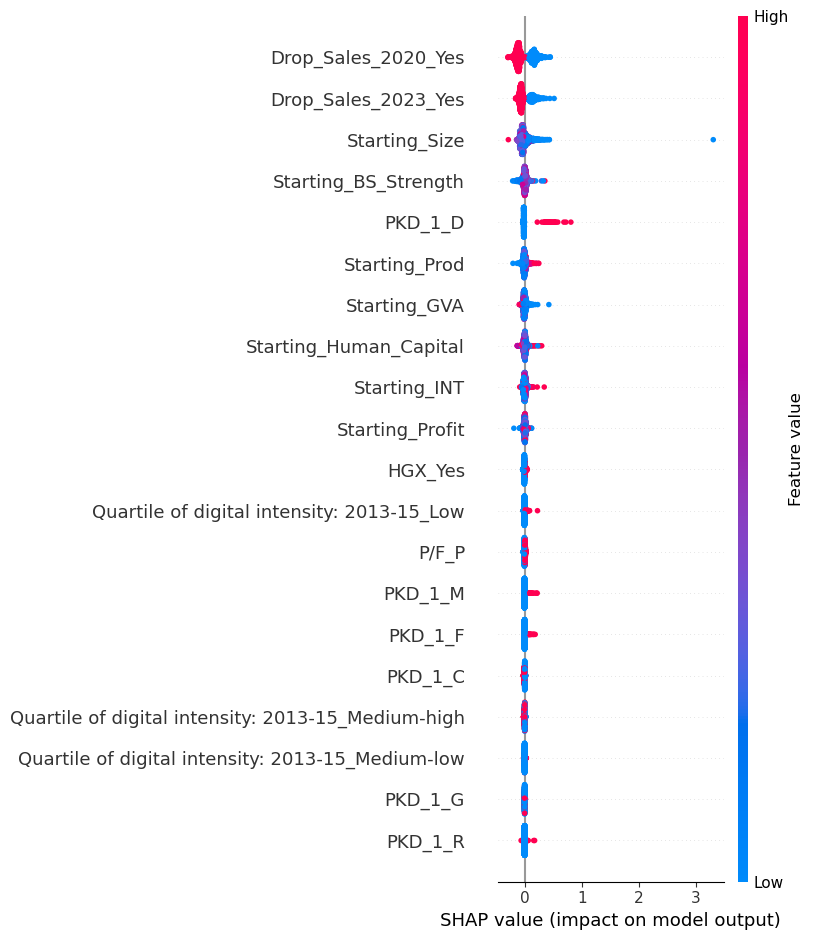

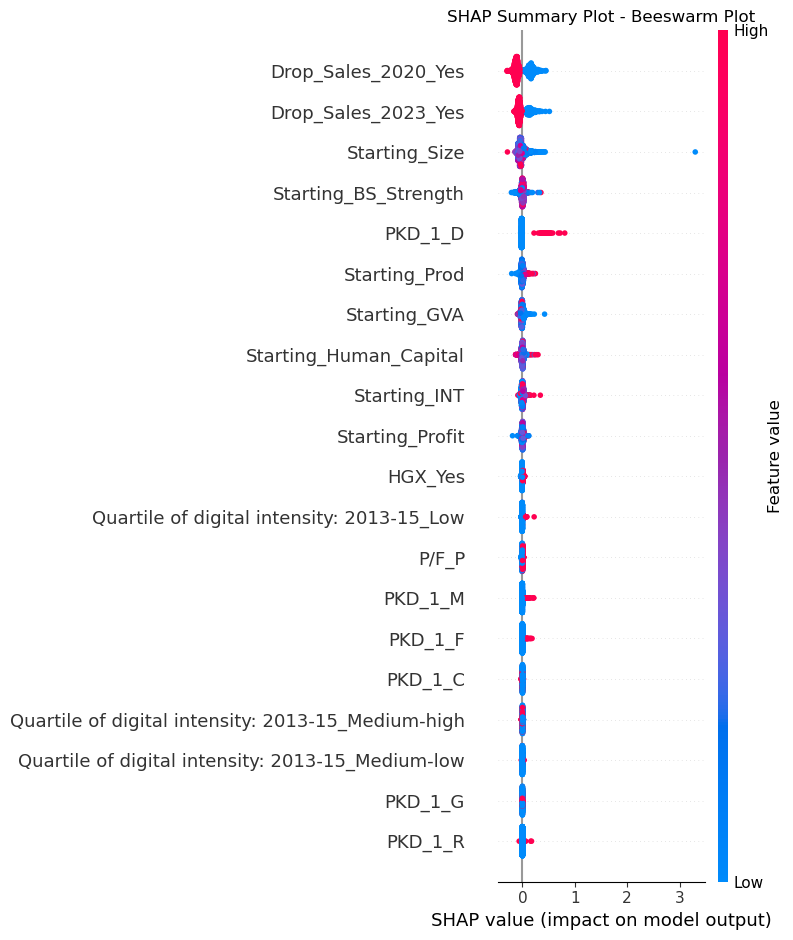

<Figure size 640x480 with 0 Axes>

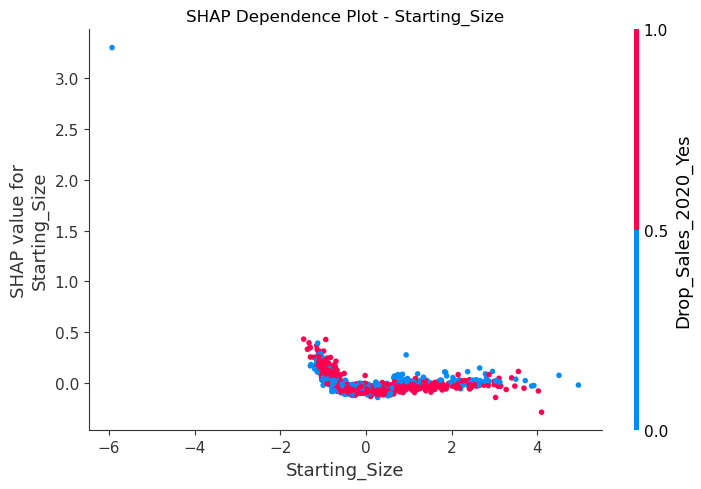

<Figure size 640x480 with 0 Axes>

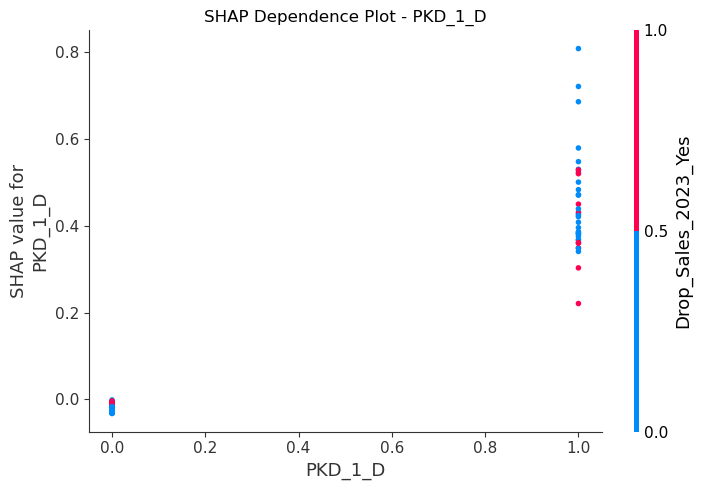

<Figure size 640x480 with 0 Axes>

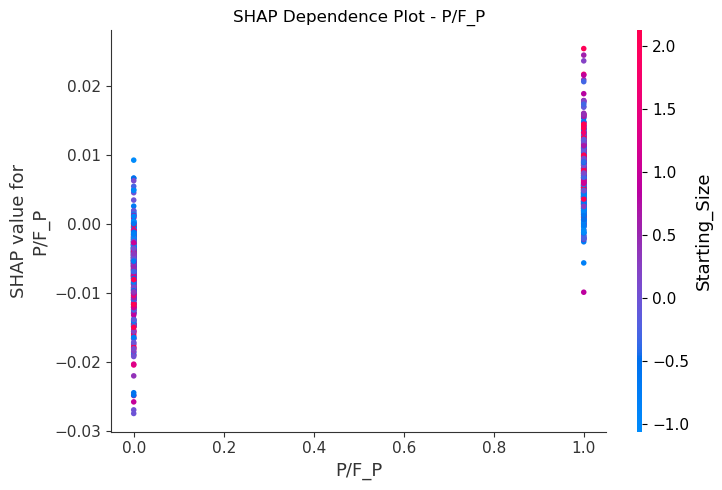

In [38]:
# Step 1: Clean feature set
X_final_cleaned = X_full.drop(columns=[col for col in all_exclusions if col in X_full.columns], errors='ignore')

# Step 2: Define target (already standardized and cleaned)
y_final = y

# Step 3: Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_final_cleaned, y_final)

# Step 4: SHAP analysis
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_final_cleaned)

# Step 6: SHAP mean importance table
shap_df = pd.DataFrame(shap_values, columns=X_final_cleaned.columns)
shap_mean_importance = shap_df.abs().mean().sort_values(ascending=False)

shap_importance_df = pd.DataFrame({
    'Feature': shap_mean_importance.index,
    'Mean |SHAP Value|': shap_mean_importance.values
})

# Step 7: Show importance table
display(shap_importance_df)

# Step 5: SHAP summary plot
shap.initjs()
shap.summary_plot(shap_values, X_final_cleaned)
plt.show()

# Step 6: SHAP Summary Plot - Beeswarm Plot
plt.figure()
shap.summary_plot(shap_values, X_final_cleaned, plot_type="dot", show=False)
plt.title("SHAP Summary Plot - Beeswarm Plot")
plt.tight_layout()
plt.savefig("SHAP_Summary_Beeswarm_Plot.png", dpi=300)
plt.show()
plt.close()

# Step 9: Generate Dependence Plots for Key Features
import re

key_features = ['Starting_Size', 'PKD_1_D', 'P/F_P']
for feature in key_features:
    plt.figure()
    shap.dependence_plot(feature, shap_values, X_final_cleaned, show=False)
    plt.title(f"SHAP Dependence Plot - {feature}")
    plt.tight_layout()
    
    # Replace special characters with an underscore
    safe_feature_name = re.sub(r'[^\w\-_\. ]', '_', feature)
    plt.savefig(f"SHAP_Dependence_{safe_feature_name}.png", dpi=300)
    plt.show()
    plt.close()

# Lasso Analysis

In [43]:
# STEP 1: Use cleaned modeling dataset from earlier steps
df_lasso = df_model.copy()  # Already Year == 2023 and excludes unwanted columns

# STEP 2: Separate features and target
X_raw = df_lasso.drop(columns=[target_variable])
y = df_lasso[target_variable]

# STEP 3: Split numeric and categorical
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns
categorical_cols = X_raw.select_dtypes(include=['object', 'category']).columns

# STEP 4: Clean and scale numeric
X_num = X_raw[numeric_cols].replace([np.inf, -np.inf], np.nan).dropna()
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_num), columns=numeric_cols, index=X_num.index)

# STEP 5: Encode categorical variables
X_cat = pd.get_dummies(X_raw.loc[X_scaled.index, categorical_cols], drop_first=True)

# STEP 6: Combine numeric + categorical
X = pd.concat([X_scaled, X_cat], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]  # Align target

# STEP 7: Run LassoCV
lasso_cv = LassoCV(cv=5, max_iter=20000, random_state=42)
lasso_cv.fit(X, y)

# STEP 8: Display selected features
lasso_coef = pd.Series(lasso_cv.coef_, index=X.columns)
selected_features = lasso_coef[lasso_coef != 0].sort_values(ascending=False)

display(HTML("<strong>✅ Lasso-selected explanatory variables:</strong>"))
display(selected_features)

LEGrowth_2023_2019                                    0,17
Sales                                                 0,12
PKD_1_D                                               0,10
LPGrowth_2023_2019                                    0,09
Productivity                                          0,03
Export Sales                                          0,02
Starting_Profit                                       0,02
LGVAGrowth_2023_2019                                  0,01
Quartile of digital intensity: 2001-03_Low            0,01
Starting_BS_Strength                                  0,01
Starting_Prod                                        -0,00
Human_Capital                                        -0,00
Quartile of digital intensity: 2001-03_Medium-high   -0,00
Depreciation                                         -0,01
Owner Type                                           -0,01
Starting_Human_Capital                               -0,01
BS_Strength                                          -0,